In [5]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [6]:
DATA_PATH = "/kaggle/input/datasets/saur3x/wifi-sensing/synthetic_csi_data_1440min.parquet"

df = pd.read_parquet(DATA_PATH)

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (17280000, 33)
       amp_0      amp_1      amp_2      amp_3      amp_4      amp_5  \
0  14.916262  15.994662  26.353529  19.284451  15.961163  13.952287   
1  15.881388  18.913483  11.906879  22.146627  16.037645  13.877267   
2  11.911693  17.846769  11.775219  20.362837  15.570219  16.446939   
3  18.860847  13.144541  11.633047  11.439113  13.471443  16.640806   
4  14.159934  11.710629  23.099676  15.314356  15.919868  15.691349   

       amp_6      amp_7      amp_8      amp_9  ...   phase_8   phase_9  \
0  12.595302  21.101038  16.295670  10.296592  ... -2.284873  1.025342   
1  12.776961  13.013695  15.237158   9.497480  ...  2.011778  3.370583   
2  16.825188  15.872265  16.604788  21.467648  ... -2.127911  1.469524   
3  18.279400  15.447737  18.720516  17.896854  ... -3.207695 -3.000940   
4  23.473412  12.324613  14.208289  15.427694  ... -0.090546  0.622783   

   phase_10  phase_11  phase_12  phase_13  phase_14  occupancy  movement  \
0 -0.673811 -0.302334  1.58977

In [7]:
amp_cols = [f"amp_{i}" for i in range(15)]
phase_cols = [f"phase_{i}" for i in range(15)]

feature_cols = amp_cols + phase_cols
target_cols = ["occupancy", "movement"]

required_cols = feature_cols + target_cols

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Eksik kolonlar var: {missing_cols}")

df = df[required_cols].copy()
df = df.loc[:, ~df.columns.duplicated()].copy()

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.ffill().bfill()

df["occupancy"] = df["occupancy"].astype(int)
df["movement"] = df["movement"].astype(int)

print("Clean shape:", df.shape)

print("\nOccupancy distribution:")
print(df["occupancy"].value_counts())
print(df["occupancy"].value_counts(normalize=True))

print("\nMovement distribution:")
print(df["movement"].value_counts())
print(df["movement"].value_counts(normalize=True))

print("\nJoint distribution:")
print(df.groupby(["occupancy", "movement"]).size())

Clean shape: (17280000, 32)

Occupancy distribution:
occupancy
1    12024000
0     5256000
Name: count, dtype: int64
occupancy
1    0.695833
0    0.304167
Name: proportion, dtype: float64

Movement distribution:
movement
0    12888000
1     4392000
Name: count, dtype: int64
movement
0    0.745833
1    0.254167
Name: proportion, dtype: float64

Joint distribution:
occupancy  movement
0          0           5256000
1          0           7632000
           1           4392000
dtype: int64


In [8]:
phase_values = df[phase_cols].values.astype(np.float32)
phase_unwrapped = np.unwrap(phase_values, axis=0)

df[phase_cols] = phase_unwrapped

print(df[phase_cols].head())

    phase_0   phase_1   phase_2   phase_3   phase_4   phase_5   phase_6  \
0 -0.540846  0.205050 -2.488475 -4.786048  1.335560  0.502684 -1.245720   
1  1.973014  2.090393 -0.697770 -3.745276 -0.779445 -2.178476 -3.407807   
2  1.971437  1.329042 -3.478360 -0.785065 -2.045788 -3.961430 -4.109251   
3  0.826516  0.497963 -6.227783  0.586849 -0.003575 -6.247188 -5.173931   
4  0.703947 -1.733253 -3.344578  3.519156  2.660878 -6.857404 -3.947026   

    phase_7   phase_8   phase_9  phase_10  phase_11  phase_12  phase_13  \
0  3.770308 -2.284873  1.025342 -0.673811 -0.302334  1.589775  4.286218   
1  6.529910 -4.271408  3.370583 -0.699195  0.101232 -0.049195  1.733633   
2  5.373446 -2.127912  1.469524 -3.564596 -1.133533  0.802645  0.623177   
3  3.701398 -3.207696  3.282245 -4.596823 -1.637304  0.644784 -1.790346   
4  5.256572 -0.090547  0.622782 -6.899667 -1.959731  0.908690 -2.875048   

   phase_14  
0 -1.053540  
1 -0.414639  
2 -0.930371  
3 -2.343142  
4 -1.472830  


In [9]:
BLOCK_SIZE = 10_000

n = len(df)
block_ids = np.arange(n) // BLOCK_SIZE
unique_blocks = np.unique(block_ids)

rng = np.random.default_rng(SEED)
rng.shuffle(unique_blocks)

num_blocks = len(unique_blocks)

train_blocks = unique_blocks[:int(num_blocks * 0.70)]
val_blocks = unique_blocks[int(num_blocks * 0.70):int(num_blocks * 0.85)]
test_blocks = unique_blocks[int(num_blocks * 0.85):]

train_mask = np.isin(block_ids, train_blocks)
val_mask = np.isin(block_ids, val_blocks)
test_mask = np.isin(block_ids, test_blocks)

print("Total blocks:", num_blocks)
print("Train blocks:", len(train_blocks))
print("Val blocks:", len(val_blocks))
print("Test blocks:", len(test_blocks))

print("\nRows:")
print("Train:", train_mask.sum())
print("Val:", val_mask.sum())
print("Test:", test_mask.sum())

print("\nTrain joint distribution:")
print(df.loc[train_mask].groupby(["occupancy", "movement"]).size())

print("\nVal joint distribution:")
print(df.loc[val_mask].groupby(["occupancy", "movement"]).size())

print("\nTest joint distribution:")
print(df.loc[test_mask].groupby(["occupancy", "movement"]).size())

Total blocks: 1728
Train blocks: 1209
Val blocks: 259
Test blocks: 260

Rows:
Train: 12090000
Val: 2590000
Test: 2600000

Train joint distribution:
occupancy  movement
0          0           3754000
1          0           5250000
           1           3086000
dtype: int64

Val joint distribution:
occupancy  movement
0          0            804000
1          0           1144000
           1            642000
dtype: int64

Test joint distribution:
occupancy  movement
0          0            698000
1          0           1238000
           1            664000
dtype: int64


In [10]:
features_raw = df[feature_cols].values.astype(np.float32)
targets_raw = df[target_cols].values.astype(np.int64)

scaler = StandardScaler()
scaler.fit(features_raw[train_mask])

features_scaled = scaler.transform(features_raw)

print("features_scaled:", features_scaled.shape)
print("targets_raw:", targets_raw.shape)

features_scaled: (17280000, 30)
targets_raw: (17280000, 2)


In [11]:
WINDOW_SIZE = 512
STRIDE = 128

def majority_label(values):
    # values shape: [window_size]
    return int(np.round(values.mean()))

def make_multitarget_windows_by_blocks(
    features,
    targets,
    block_ids,
    selected_blocks,
    window_size=512,
    stride=128
):
    X_windows = []
    y_windows = []

    for block in selected_blocks:
        idx = np.where(block_ids == block)[0]

        if len(idx) < window_size:
            continue

        block_features = features[idx]
        block_targets = targets[idx]

        for start in range(0, len(block_features) - window_size + 1, stride):
            end = start + window_size

            x_win = block_features[start:end]

            occ_label = majority_label(block_targets[start:end, 0])
            mov_label = majority_label(block_targets[start:end, 1])

            X_windows.append(x_win)
            y_windows.append([occ_label, mov_label])

    X_windows = np.array(X_windows, dtype=np.float32)
    y_windows = np.array(y_windows, dtype=np.int64)

    return X_windows, y_windows


X_train, y_train = make_multitarget_windows_by_blocks(
    features_scaled,
    targets_raw,
    block_ids,
    train_blocks,
    WINDOW_SIZE,
    STRIDE
)

X_val, y_val = make_multitarget_windows_by_blocks(
    features_scaled,
    targets_raw,
    block_ids,
    val_blocks,
    WINDOW_SIZE,
    STRIDE
)

X_test, y_test = make_multitarget_windows_by_blocks(
    features_scaled,
    targets_raw,
    block_ids,
    test_blocks,
    WINDOW_SIZE,
    STRIDE
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

print("\nTrain labels occupancy:")
print(pd.Series(y_train[:, 0]).value_counts(normalize=True))

print("\nTrain labels movement:")
print(pd.Series(y_train[:, 1]).value_counts(normalize=True))

print("\nTest labels occupancy:")
print(pd.Series(y_test[:, 0]).value_counts(normalize=True))

print("\nTest labels movement:")
print(pd.Series(y_test[:, 1]).value_counts(normalize=True))

print("\nTrain joint labels:")
print(pd.DataFrame(y_train, columns=target_cols).groupby(target_cols).size())

print("\nTest joint labels:")
print(pd.DataFrame(y_test, columns=target_cols).groupby(target_cols).size())

X_train: (90675, 512, 30) y_train: (90675, 2)
X_val: (19425, 512, 30) y_val: (19425, 2)
X_test: (19500, 512, 30) y_test: (19500, 2)

Train labels occupancy:
1    0.689506
0    0.310494
Name: proportion, dtype: float64

Train labels movement:
0    0.74477
1    0.25523
Name: proportion, dtype: float64

Test labels occupancy:
1    0.731487
0    0.268513
Name: proportion, dtype: float64

Test labels movement:
0    0.744769
1    0.255231
Name: proportion, dtype: float64

Train joint labels:
occupancy  movement
0          0           28154
1          0           39378
           1           23143
dtype: int64

Test joint labels:
occupancy  movement
0          0           5236
1          0           9287
           1           4977
dtype: int64


In [12]:
def window_stats(X):
    mean = X.mean(axis=1)
    std = X.std(axis=1)
    minv = X.min(axis=1)
    maxv = X.max(axis=1)

    return np.concatenate([mean, std, minv, maxv], axis=1)


X_train_stat = window_stats(X_train)
X_val_stat = window_stats(X_val)
X_test_stat = window_stats(X_test)

print("X_train_stat:", X_train_stat.shape)
print("X_val_stat:", X_val_stat.shape)
print("X_test_stat:", X_test_stat.shape)

X_train_stat: (90675, 120)
X_val_stat: (19425, 120)
X_test_stat: (19500, 120)


In [13]:
def evaluate_multitarget_predictions(name, y_true, y_pred):
    print(name)
    print("-" * len(name))

    for i, target in enumerate(target_cols):
        acc = accuracy_score(y_true[:, i], y_pred[:, i])
        precision = precision_score(y_true[:, i], y_pred[:, i], zero_division=0)
        recall = recall_score(y_true[:, i], y_pred[:, i], zero_division=0)
        f1 = f1_score(y_true[:, i], y_pred[:, i], zero_division=0)

        print(f"\nTarget: {target}")
        print("Accuracy :", acc)
        print("Precision:", precision)
        print("Recall   :", recall)
        print("F1-score :", f1)
        print(classification_report(y_true[:, i], y_pred[:, i], zero_division=0))

    exact_match = np.mean(np.all(y_true == y_pred, axis=1))
    print("\nExact Match Accuracy:", exact_match)


majority_occ = pd.Series(y_train[:, 0]).mode()[0]
majority_mov = pd.Series(y_train[:, 1]).mode()[0]

baseline_preds = np.tile(
    np.array([majority_occ, majority_mov]),
    (len(y_test), 1)
)

print("Majority occupancy:", majority_occ)
print("Majority movement :", majority_mov)

evaluate_multitarget_predictions("Baseline Test", y_test, baseline_preds)

Majority occupancy: 1
Majority movement : 0
Baseline Test
-------------

Target: occupancy
Accuracy : 0.7314871794871795
Precision: 0.7314871794871795
Recall   : 1.0
F1-score : 0.8449235872526952
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      5236
           1       0.73      1.00      0.84     14264

    accuracy                           0.73     19500
   macro avg       0.37      0.50      0.42     19500
weighted avg       0.54      0.73      0.62     19500


Target: movement
Accuracy : 0.7447692307692307
Precision: 0.0
Recall   : 0.0
F1-score : 0.0
              precision    recall  f1-score   support

           0       0.74      1.00      0.85     14523
           1       0.00      0.00      0.00      4977

    accuracy                           0.74     19500
   macro avg       0.37      0.50      0.43     19500
weighted avg       0.55      0.74      0.64     19500


Exact Match Accuracy: 0.47625641025641025


In [14]:
MAX_TRAIN_WINDOWS = 20_000

if len(X_train_stat) > MAX_TRAIN_WINDOWS:
    rng = np.random.default_rng(SEED)
    sample_idx = rng.choice(len(X_train_stat), size=MAX_TRAIN_WINDOWS, replace=False)

    X_train_rf = X_train_stat[sample_idx]
    y_train_rf = y_train[sample_idx]
else:
    X_train_rf = X_train_stat
    y_train_rf = y_train

print("RF train subset:", X_train_rf.shape)
print("RF target subset:", y_train_rf.shape)

base_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=18,
    min_samples_leaf=3,
    max_features="sqrt",
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

multi_rf = MultiOutputClassifier(base_rf, n_jobs=-1)

start_time = time.time()

multi_rf.fit(X_train_rf, y_train_rf)

print("MultiOutput RF training time:", time.time() - start_time, "seconds")

RF train subset: (20000, 120)
RF target subset: (20000, 2)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    5.2s
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    6.1s finished
[Parallel(n_jobs=-1)]: Done 192 tasks      | elapsed:   14.7s


MultiOutput RF training time: 17.336572647094727 seconds


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   15.2s finished


In [15]:
rf_train_preds = multi_rf.predict(X_train_stat)
rf_val_preds = multi_rf.predict(X_val_stat)
rf_test_preds = multi_rf.predict(X_test_stat)

evaluate_multitarget_predictions("RandomForest Train", y_train, rf_train_preds)
evaluate_multitarget_predictions("RandomForest Val", y_val, rf_val_preds)
evaluate_multitarget_predictions("RandomForest Test", y_test, rf_test_preds)

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.6s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Done 192 tasks      |

RandomForest Train
------------------

Target: occupancy
Accuracy : 0.9990184725668597
Precision: 0.9986422159036452
Recall   : 0.9999360214967771
F1-score : 0.9992886999192794
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28154
           1       1.00      1.00      1.00     62521

    accuracy                           1.00     90675
   macro avg       1.00      1.00      1.00     90675
weighted avg       1.00      1.00      1.00     90675


Target: movement
Accuracy : 0.9999779432037497
Precision: 0.9999135882480017
Recall   : 1.0
F1-score : 0.9999567922571725
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     67532
           1       1.00      1.00      1.00     23143

    accuracy                           1.00     90675
   macro avg       1.00      1.00      1.00     90675
weighted avg       1.00      1.00      1.00     90675


Exact Match Accuracy: 0.9989964157706093
Rand

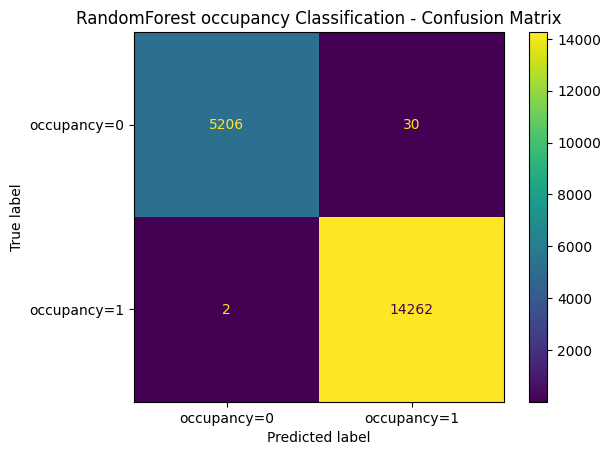

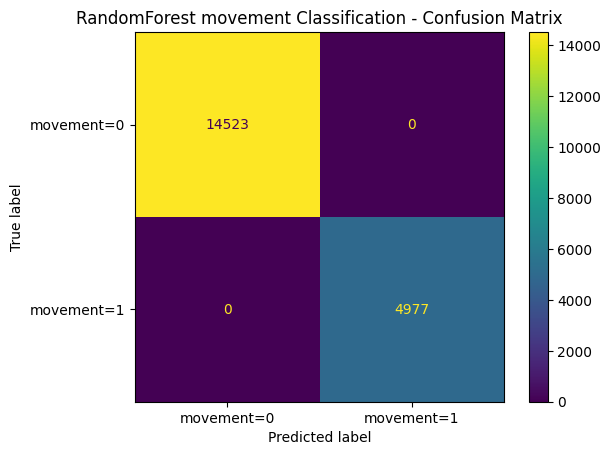

In [16]:
for i, target in enumerate(target_cols):
    cm = confusion_matrix(y_test[:, i], rf_test_preds[:, i])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f"{target}=0", f"{target}=1"]
    )

    disp.plot(values_format="d")
    plt.title(f"RandomForest {target} Classification - Confusion Matrix")
    plt.grid(False)
    plt.show()

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 192 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 200 out of 200 | elapsed:    0.1s finished


Occupancy probability stats:
min : 0.0
max : 1.0
mean: 0.7311758014014115
std : 0.4394483642669196

Movement probability stats:
min : 0.0
max : 1.0
mean: 0.2553308105784419
std : 0.4358097706927508


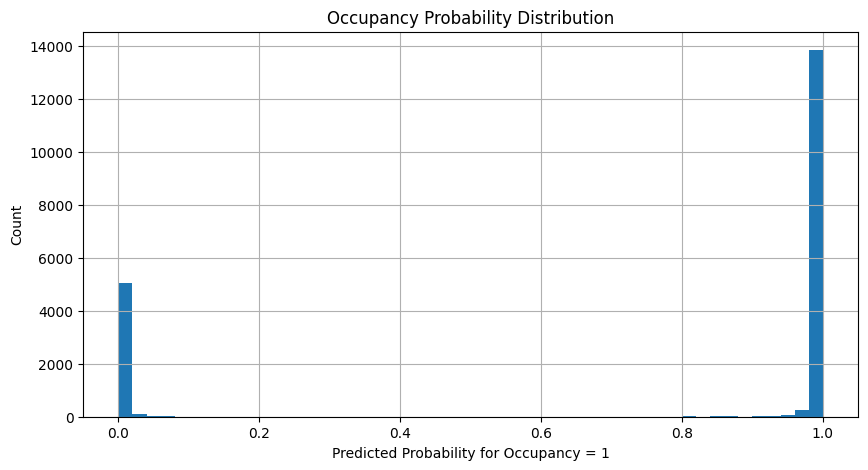

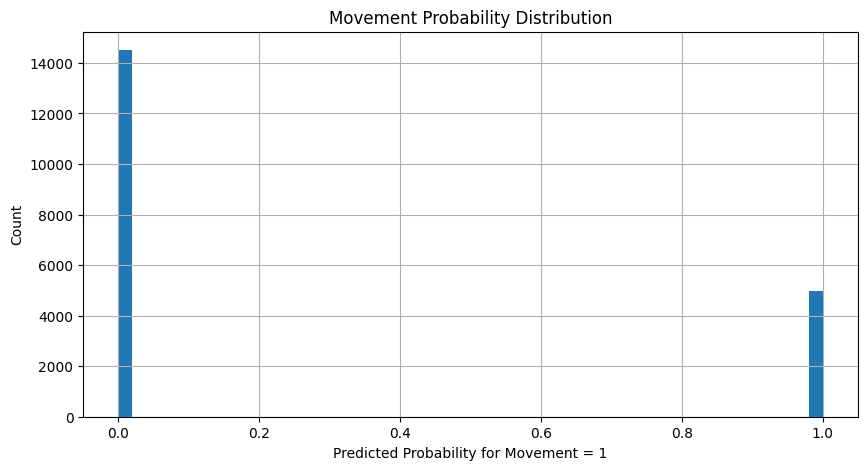

In [17]:
# MultiOutputClassifier stores one estimator per target.
# estimators_[0] → occupancy model
# estimators_[1] → movement model

occ_probs = multi_rf.estimators_[0].predict_proba(X_test_stat)[:, 1]
mov_probs = multi_rf.estimators_[1].predict_proba(X_test_stat)[:, 1]

print("Occupancy probability stats:")
print("min :", occ_probs.min())
print("max :", occ_probs.max())
print("mean:", occ_probs.mean())
print("std :", occ_probs.std())

print("\nMovement probability stats:")
print("min :", mov_probs.min())
print("max :", mov_probs.max())
print("mean:", mov_probs.mean())
print("std :", mov_probs.std())

plt.figure(figsize=(10, 5))
plt.hist(occ_probs, bins=50)
plt.xlabel("Predicted Probability for Occupancy = 1")
plt.ylabel("Count")
plt.title("Occupancy Probability Distribution")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.hist(mov_probs, bins=50)
plt.xlabel("Predicted Probability for Movement = 1")
plt.ylabel("Count")
plt.title("Movement Probability Distribution")
plt.grid(True)
plt.show()


Top 20 Feature Importances for occupancy
        feature  importance
40   std_amp_10    0.164389
43   std_amp_13    0.149075
37    std_amp_7    0.110504
30    std_amp_0    0.098215
44   std_amp_14    0.081787
39    std_amp_9    0.063499
31    std_amp_1    0.061559
36    std_amp_6    0.040000
41   std_amp_11    0.037098
73   min_amp_13    0.027821
42   std_amp_12    0.021158
70   min_amp_10    0.017543
100  max_amp_10    0.014119
103  max_amp_13    0.013323
74   min_amp_14    0.011103
38    std_amp_8    0.011058
90    max_amp_0    0.009044
67    min_amp_7    0.007706
104  max_amp_14    0.007669
32    std_amp_2    0.007347


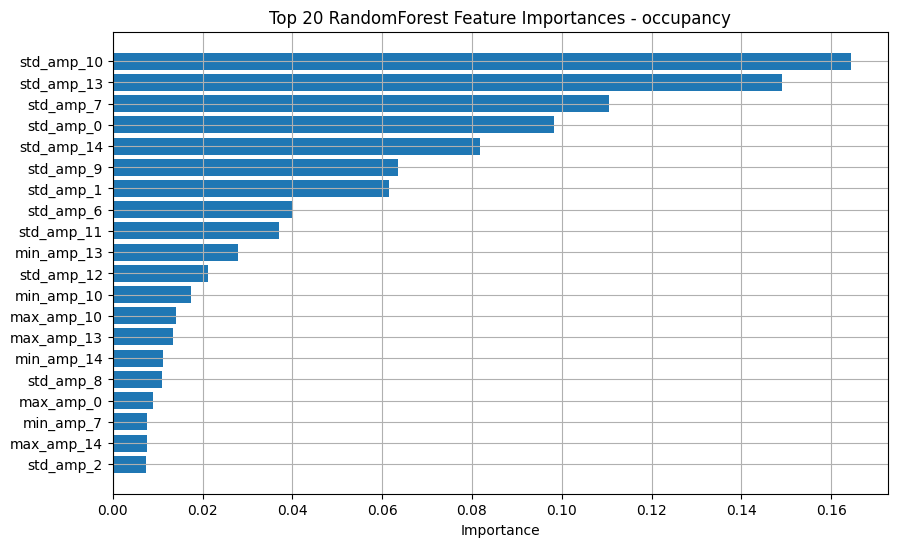


Top 20 Feature Importances for movement
       feature  importance
40  std_amp_10    0.095070
32   std_amp_2    0.075234
31   std_amp_1    0.055179
43  std_amp_13    0.055026
33   std_amp_3    0.050155
30   std_amp_0    0.050105
39   std_amp_9    0.050070
37   std_amp_7    0.040146
38   std_amp_8    0.040109
44  std_amp_14    0.040077
71  min_amp_11    0.039793
35   std_amp_5    0.038855
36   std_amp_6    0.035162
34   std_amp_4    0.030029
92   max_amp_2    0.029869
41  std_amp_11    0.025073
42  std_amp_12    0.025047
62   min_amp_2    0.024879
72  min_amp_12    0.019910
93   max_amp_3    0.019899


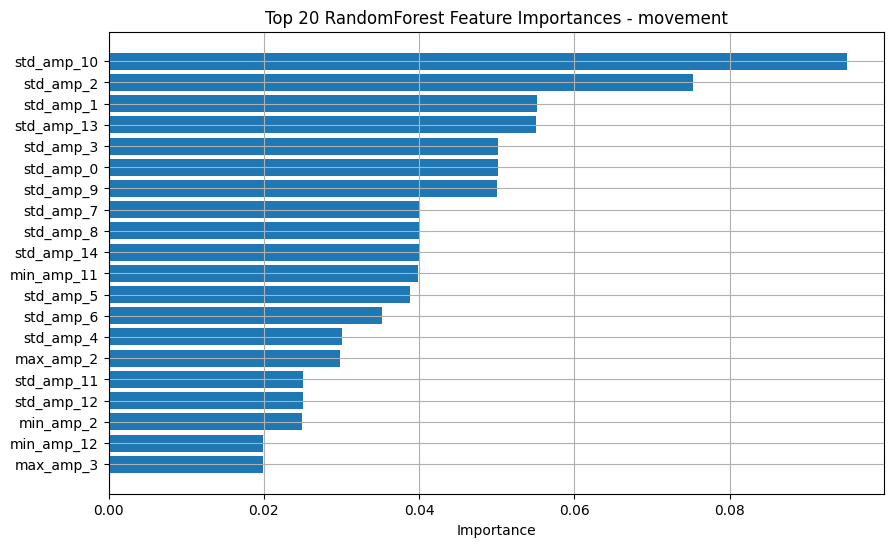

In [18]:
feature_names = []

stat_names = ["mean", "std", "min", "max"]

for stat in stat_names:
    for col in feature_cols:
        feature_names.append(f"{stat}_{col}")


for i, target in enumerate(target_cols):
    importances = multi_rf.estimators_[i].feature_importances_

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    print(f"\nTop 20 Feature Importances for {target}")
    print(importance_df.head(20))

    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df.head(20)["feature"][::-1],
        importance_df.head(20)["importance"][::-1]
    )
    plt.xlabel("Importance")
    plt.title(f"Top 20 RandomForest Feature Importances - {target}")
    plt.grid(True)
    plt.show()